In [ ]:
# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="lsXqkr4nP217WxcbT5nC")
# project = rf.workspace("computer-vision-2v7mb").project("crowd-counting-dataset-w3o7w-l8c0s")
# version = project.version(1)
# dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to crowd-counting-dataset-1 in yolov11:: 100%|██████████| 5808/5808 [00:01<00:00, 3958.79it/s]


In [ ]:
import os

for dirpath, dirnames, filenames in os.walk("crowd-counting-dataset-1"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} files in {dirpath}")

There are 3 directories and 3 files in crowd-counting-dataset-1
There are 2 directories and 0 files in crowd-counting-dataset-1/valid
There are 0 directories and 382 files in crowd-counting-dataset-1/valid/images
There are 0 directories and 382 files in crowd-counting-dataset-1/valid/labels
There are 2 directories and 0 files in crowd-counting-dataset-1/test
There are 0 directories and 231 files in crowd-counting-dataset-1/test/images
There are 0 directories and 231 files in crowd-counting-dataset-1/test/labels
There are 2 directories and 0 files in crowd-counting-dataset-1/train
There are 0 directories and 2285 files in crowd-counting-dataset-1/train/images
There are 0 directories and 2285 files in crowd-counting-dataset-1/train/labels


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image

IMAGE_SIZE = (400, 400)
BATCH_SIZE = 16  # Reduce this if it still crashes

# ADD — replace old label_to_matrix
from scipy.ndimage import gaussian_filter

def label_to_matrix_counting(label_path, image_size=IMAGE_SIZE):
    matrix = np.zeros(image_size, dtype=np.float32)

    if os.path.getsize(label_path.numpy().decode()) == 0:
        return matrix[..., np.newaxis]

    label = pd.read_csv(label_path.numpy().decode(), sep=' ', header=None)
    points = (label[[1, 2]].values * image_size[0]).astype(int)
    points = np.clip(points, 0, image_size[0] - 1)
    matrix[points[:, 1], points[:, 0]] = 1.0

    # gaussian_filter preserves the sum, so each blob integrates to ~1
    matrix = gaussian_filter(matrix, sigma=3)

    return matrix[..., np.newaxis]


def load_sample(img_path, label_path):
    """Lazily load a single image-label pair — called per sample, not all at once."""

    # --- Image ---
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # (400, 400, 3)

    # --- Label matrix ---
    matrix = tf.py_function(
        func=label_to_matrix_counting,
        inp=[label_path],
        Tout=tf.float32
    )
    matrix.set_shape([*IMAGE_SIZE, 1])  # (400, 400, 1)

    return img, matrix


def make_tf_dataset(image_dir, label_dir, batch_size=BATCH_SIZE, shuffle=True):
    # Build paired file path lists
    image_files = sorted([
        f for f in os.listdir(image_dir) if f.endswith('.jpg')
    ])

    img_paths, lbl_paths = [], []
    for fname in image_files:
        lbl_fname = fname.replace('.jpg', '.txt')
        lbl_path  = os.path.join(label_dir, lbl_fname)
        if os.path.exists(lbl_path):
            img_paths.append(os.path.join(image_dir, fname))
            lbl_paths.append(lbl_path)

    print(f"Found {len(img_paths)} samples in {image_dir}")

    dataset = tf.data.Dataset.from_tensor_slices((img_paths, lbl_paths))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=200, reshuffle_each_iteration=True)

    dataset = (dataset
               .map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(batch_size)
               .prefetch(tf.data.AUTOTUNE))

    return dataset


# --- Build datasets ---
BASE = 'crowd-counting-dataset-1'

train_ds = make_tf_dataset(f'{BASE}/train/images', f'{BASE}/train/labels', shuffle=True)
valid_ds = make_tf_dataset(f'{BASE}/valid/images', f'{BASE}/valid/labels', shuffle=False)
test_ds  = make_tf_dataset(f'{BASE}/test/images',  f'{BASE}/test/labels',  shuffle=False)

# --- Verify ---
for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)   # (16, 400, 400, 3)
    print("Label batch:", labels.shape)   # (16, 400, 400, 1)

Found 2285 samples in crowd-counting-dataset-1/train/images
Found 382 samples in crowd-counting-dataset-1/valid/images
Found 231 samples in crowd-counting-dataset-1/test/images
Image batch: (16, 400, 400, 3)
Label batch: (16, 400, 400, 1)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def visualize_overlay(dataset, num_samples=4, alpha=0.5):
    fig, axes = plt.subplots(2, num_samples, figsize=(4 * num_samples, 8))

    for images, labels in dataset.take(1):
        for i in range(min(num_samples, images.shape[0])):
            img   = images[i].numpy()
            label = labels[i].numpy()[..., 0]

            axes[0, i].imshow(img)
            axes[0, i].set_title(f"Image {i+1}", fontsize=10)
            axes[0, i].axis("off")

            axes[1, i].imshow(img)
            heatmap = axes[1, i].imshow(
                label,
                cmap="hot",
                alpha=alpha,
                vmin=0,
                vmax=label.max() or 1e-6,  # ← scale to actual peak, not 1.0
            )
            plt.colorbar(heatmap, ax=axes[1, i], fraction=0.046, pad=0.04)
            axes[1, i].set_title(f"Overlay {i+1}\ncount≈{label.sum():.1f}", fontsize=10)
            axes[1, i].axis("off")

    fig.suptitle("Image  |  Gaussian density overlay", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("overlay_preview.png", dpi=150, bbox_inches="tight")
    plt.show()




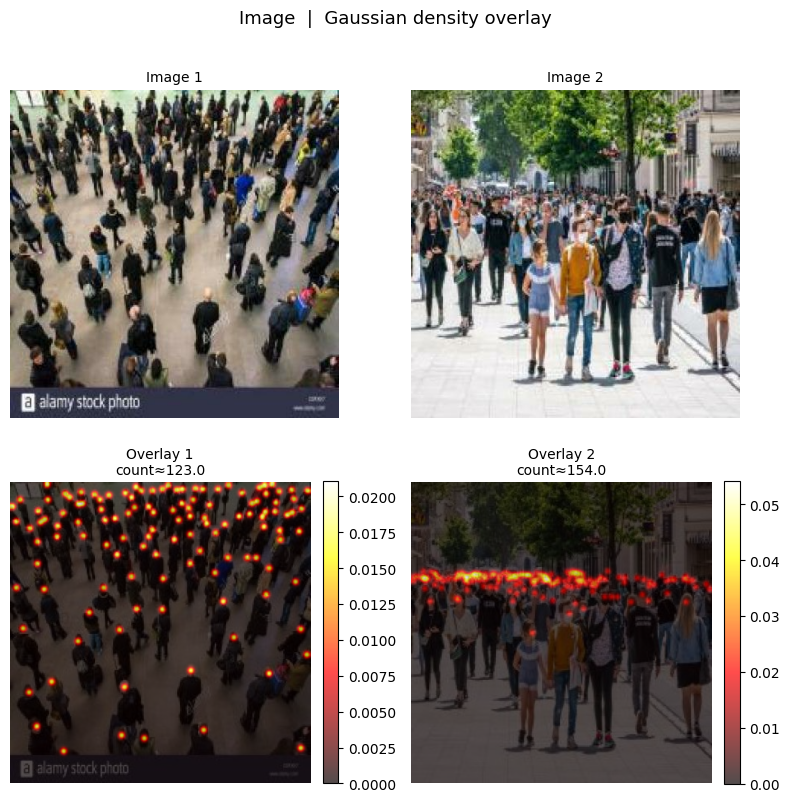

In [ ]:
# Call it with whichever split you want to inspect
visualize_overlay(test_ds, num_samples=2, alpha=0.7)

In [ ]:
def count_people(predicted_matrix, scale_factor=None):
    """
    Sum the density map to estimate crowd count.
    scale_factor calibrates the sum to actual headcount
    (computed from your training data).
    """
    total = predicted_matrix.squeeze().sum()
    if scale_factor:
        return total * scale_factor
    return total

In [ ]:
def predict_crowd(model, image_tensor):
    pred = model.predict(image_tensor[np.newaxis, ...])[0]  # (400, 400, 1)
    count = pred.squeeze().sum()
    return count, pred

## Testing

In [ ]:
import tensorflow as tf

def weighted_focal_loss(gamma=2.0, pos_weight=1000.0):
    bce = tf.keras.losses.BinaryFocalCrossentropy(gamma=gamma)
    def loss(y_true, y_pred):
        weights = 1.0 + y_true * (pos_weight - 1.0)  # upweight positives
        return tf.reduce_mean(bce(y_true, y_pred) * tf.squeeze(weights, -1))
    return loss


custom_objects = {
    'loss': weighted_focal_loss
}

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/Stampede_Prediction/67_precision49_recall.keras',
    custom_objects=custom_objects
)

In [ ]:
def test_image(model, image_path=r'/content/crowd-counting-dataset-1/test/images/img_1002_jpg.rf.3b81c3ad5100760bced785e5e5eaa82a.jpg'):

    # Getting label
    label_path = image_path.replace('.jpg', '.txt').replace('images', 'labels')

    from scipy.ndimage import gaussian_filter

    def label_to_matrix_counting(label_path, image_size=400):
        matrix = np.zeros(image_size, dtype=np.float32)

        if os.path.getsize(label_path.numpy().decode()) == 0:
            return matrix[..., np.newaxis]

        label = pd.read_csv(label_path.numpy().decode(), sep=' ', header=None)
        points = (label[[1, 2]].values * image_size[0]).astype(int)
        points = np.clip(points, 0, image_size[0] - 1)
        matrix[points[:, 1], points[:, 0]] = 1.0

        # gaussian_filter preserves the sum, so each blob integrates to ~1
        matrix = gaussian_filter(matrix, sigma=3)

        return matrix[..., np.newaxis]


    def load_sample(image_path, label_path):
        """Lazily load a single image-label pair — called per sample, not all at once."""

        # --- Image ---
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMAGE_SIZE)
        img = tf.cast(img, tf.float32) / 255.0  # (400, 400, 3)

        # --- Label matrix ---
        matrix = tf.py_function(
            func=label_to_matrix_counting,
            inp=[label_path],
            Tout=tf.float32
        )
        matrix.set_shape([*IMAGE_SIZE, 1])  # (400, 400, 1)

        return img, matrix

        matrix_pred = model.predict(img)

        # Visualize and compare predicted vs actual results





In [ ]:
def test_image(model, image_path=r'/content/crowd-counting-dataset-1/test/images/img_1002_jpg.rf.3b81c3ad5100760bced785e5e5eaa82a.jpg', alpha=0.6, threshold=0.5):
    from scipy.ndimage import gaussian_filter

    # ── 1. Derive label path ─────────────────────────────────────────────────
    label_path = image_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

    # ── 2. Load & preprocess image ───────────────────────────────────────────
    img_tensor = tf.io.read_file(image_path)
    img_tensor = tf.image.decode_jpeg(img_tensor, channels=3)
    img_tensor = tf.image.resize(img_tensor, IMAGE_SIZE)
    img_tensor = tf.cast(img_tensor, tf.float32) / 255.0   # (H, W, 3)
    img_np     = img_tensor.numpy()

    # ── 3. Build ground-truth density map ───────────────────────────────────
    matrix = np.zeros(IMAGE_SIZE, dtype=np.float32)
    if os.path.getsize(label_path) > 0:
        label  = pd.read_csv(label_path, sep=' ', header=None)
        points = (label[[1, 2]].values * IMAGE_SIZE[0]).astype(int)
        points = np.clip(points, 0, IMAGE_SIZE[0] - 1)
        matrix[points[:, 1], points[:, 0]] = 1.0
        matrix = gaussian_filter(matrix, sigma=3)
    actual_map   = matrix                        # (H, W)
    actual_count = actual_map.sum()

    # ── 4. Predict ───────────────────────────────────────────────────────────
    pred_map = model.predict(img_tensor[np.newaxis, ...])[0, ..., 0]   # (H, W)
    pred_map[pred_map < threshold] = 0
    pred_count = pred_map.sum()

    # ── 5. Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    titles = [
        f"Predicted  count ≈ {pred_count:.1f}",
        f"Actual  count ≈ {actual_count:.1f}",
    ]
    maps = [pred_map, actual_map]

    for ax, density, title in zip(axes, maps, titles):
        ax.imshow(img_np)
        heatmap = ax.imshow(
            density,
            cmap="hot",
            alpha=alpha,
            vmin=0,
            vmax=density.max() or 1e-6,
        )
        plt.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    fig.suptitle(os.path.basename(image_path), fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig("test_image_overlay.png", dpi=150, bbox_inches="tight")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


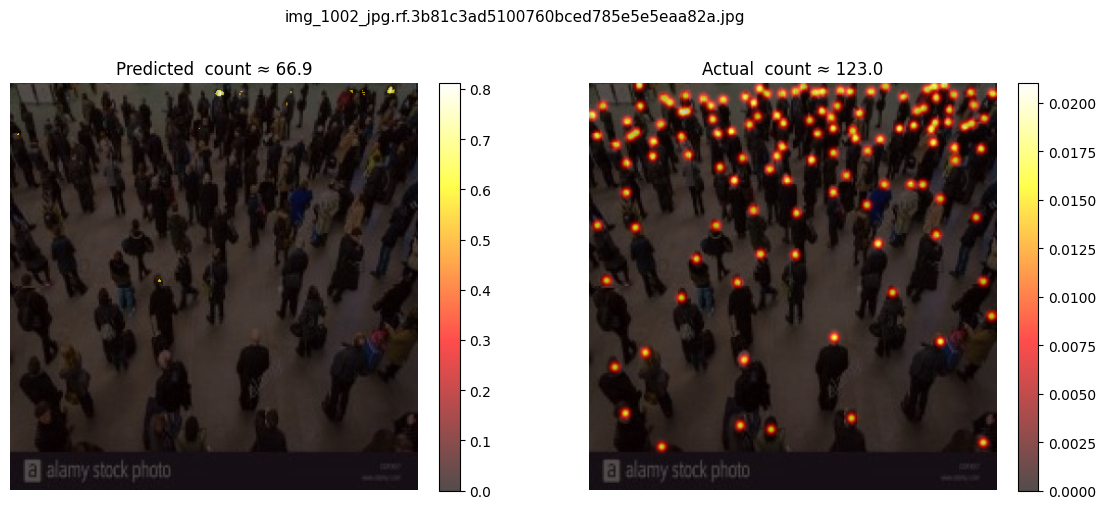

In [ ]:
test_image(model, alpha=0.7, threshold=0.52)

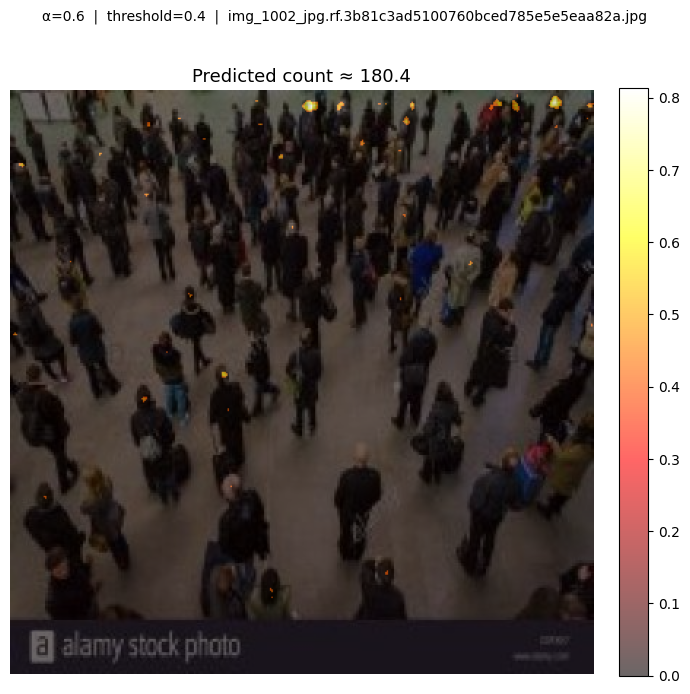

In [ ]:
def predict_image(model, image_path, alpha=0.6, pred_threshold=0.4):

    # ── 1. Load & preprocess image ───────────────────────────────────────────
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img_np = img.numpy()

    # ── 2. Predict density map ───────────────────────────────────────────────
    img_batch = img[np.newaxis, ...]
    pred_map = model.predict(img_batch, verbose=0)[0, ..., 0]
    pred_map[pred_map < pred_threshold] = 0

    # ── 3. Plot ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img_np)
    heatmap = ax.imshow(
        pred_map,
        cmap="hot",
        alpha=alpha,
        vmin=0,
        vmax=pred_map.max() or 1e-6,
    )
    plt.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Predicted count ≈ {pred_map.sum():.1f}", fontsize=13)
    ax.axis("off")

    fig.suptitle(f"α={alpha}  |  threshold={pred_threshold}  |  {os.path.basename(image_path)}", fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig("predict_image_overlay.png", dpi=150, bbox_inches="tight")
    plt.show()

# Usage
predict_image(model, image_path='crowd-counting-dataset-1/test/images/img_1002_jpg.rf.3b81c3ad5100760bced785e5e5eaa82a.jpg')

In [ ]:
# Run Locally, CV2 doesn't work on colab

def predict_video(model, source=0, alpha=0.6, pred_threshold=0.2,
                  grid_cols=8, grid_rows=8,
                  density_threshold=4.0,   # people per m²
                  meters_per_pixel=0.05):  # ← tune this to your scene
    """
    meters_per_pixel: how many real-world metres one pixel represents.
                      Calibrate by measuring a known object in the scene.
    grid_cols/rows:   how finely to divide the image for density checking.
    density_threshold: people/m² that triggers a flag.
    """
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        print(f"Could not open source: {source}")
        return

    # Pre-compute cell pixel dimensions and real-world area
    cell_h = IMAGE_SIZE[0] // grid_rows
    cell_w = IMAGE_SIZE[1] // grid_cols
    cell_area_m2 = (cell_h * meters_per_pixel) * (cell_w * meters_per_pixel)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # ── 1. Preprocess ────────────────────────────────────────────────────
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = cv2.resize(frame_rgb, IMAGE_SIZE) / 255.0
        img_batch = img[np.newaxis, ...].astype(np.float32)

        # ── 2. Predict ───────────────────────────────────────────────────────
        pred_map = model(img_batch, training=False).numpy()[0, ..., 0]
        pred_map[pred_map < pred_threshold] = 0
        total_count = pred_map.sum()

        # ── 3. Heatmap overlay ───────────────────────────────────────────────
        vmax = pred_map.max() or 1e-6
        heatmap_rgb = (plt.get_cmap("hot")(pred_map / vmax)[..., :3] * 255).astype(np.uint8)
        overlay = cv2.addWeighted(frame_rgb.astype(np.uint8), 1.0, heatmap_rgb, alpha, 0)

        # ── 4. Grid density check & flagging ─────────────────────────────────
        any_flagged = False
        for row in range(grid_rows):
            for col in range(grid_cols):
                y0, y1 = row * cell_h, (row + 1) * cell_h
                x0, x1 = col * cell_w, (col + 1) * cell_w

                cell_count   = pred_map[y0:y1, x0:x1].sum()
                cell_density = cell_count / cell_area_m2   # people / m²

                if cell_density >= density_threshold:
                    any_flagged = True
                    # Red rectangle around flagged cell
                    cv2.rectangle(overlay, (x0, y0), (x1, y1), (255, 0, 0), 2)
                    # Density label inside cell
                    cv2.putText(
                        overlay,
                        f"{cell_density:.1f}/m²",
                        org=(x0 + 4, y0 + 20),
                        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                        fontScale=0.45,
                        color=(255, 0, 0),
                        thickness=1,
                        lineType=cv2.LINE_AA,
                    )

        # ── 5. HUD text ──────────────────────────────────────────────────────
        status = "!! OVERCROWDED !!" if any_flagged else "OK"
        status_color = (255, 0, 0) if any_flagged else (0, 255, 0)

        cv2.putText(overlay, f"Count: {total_count:.1f}",
                    (15, 35),  cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 80, 0), 2, cv2.LINE_AA)
        cv2.putText(overlay, status,
                    (15, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.0, status_color,   2, cv2.LINE_AA)

        out_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
        cv2.imshow("Crowd Counter  |  Q to quit", out_bgr)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


# Usage
predict_video(model, source=0, meters_per_pixel=0.05, density_threshold=4.0, grid_cols=8, grid_rows=8)